# Chapter 7: Quantum Optimizer & QCI Data Analysis

Welcome to Chapter 6! This notebook explains the last two tabs of the QRANDOPT dashboard for lay audiences.

## 1. Quantum Optimizer (Dirac-3) 🔬
This tool finds the lowest-energy solution to your problem using real quantum hardware. Lower energy means a better answer.

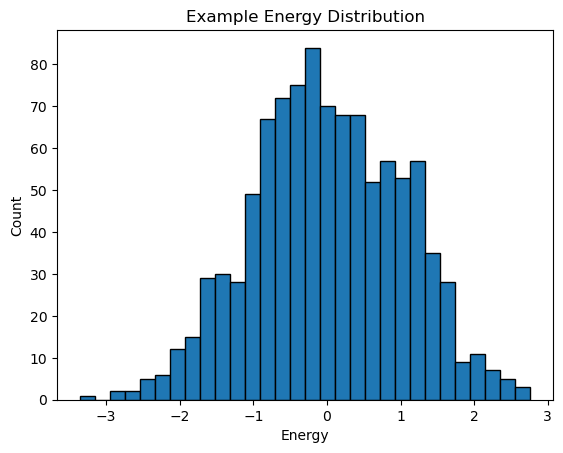

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate energy samples
energies = np.random.normal(loc=0, scale=1, size=1000)

plt.hist(energies, bins=30, edgecolor='black')
plt.title('Example Energy Distribution')
plt.xlabel('Energy')
plt.ylabel('Count')
plt.show()

A **histogram** of energies shows how often each solution quality occurs. The lowest bar on the left is your best solution.

### Sample Solutions Table 📋
Each row lists a bit pattern (solution), its energy, and how often it appeared.

In [2]:
import pandas as pd

# Example table
solutions = pd.DataFrame({
    'Solution': ['010', '101', '110'],
    'Energy': [-2.3, -1.8, -1.5],
    'Count': [500, 300, 200]
})
solutions

,Solution,Energy,Count
0,010,-2.3,500
1,101,-1.8,300
2,110,-1.5,200


## 2. QCI Data Analysis 📡
Here, we analyze real output from QCI hardware:

- **Shannon Entropy & Min-Entropy:** Measures of randomness (0 = none, 1 = perfect).
- **SP800-22 PassRate:** How many standard randomness tests the data passes.
- **Extractor Performance:** Bias, rate, and pass rate on real hardware data.

In [3]:
import numpy as np
import pandas as pd

# Simulate hardware bitstream
bits = np.random.randint(0, 2, size=2000)
p1 = bits.mean()
entropy = -(p1*np.log2(p1+1e-9) + (1-p1)*np.log2(1-p1+1e-9))
min_entropy = -np.log2(max(p1, 1-p1))
print(f'Shannon Entropy: {entropy:.3f}')
print(f'Min-Entropy: {min_entropy:.3f}')

Shannon Entropy: 1.000
Min-Entropy: 0.981


### Extractor Performance on Hardware Data
We run the same extractors and compare metrics:

In [4]:
import pandas as pd

# Example performance
perf = pd.DataFrame({
    'Extractor': ['Von Neumann', 'Meta-RL'],
    'Post-Bias': [0.03, 0.01],
    'Rate': [0.6, 0.7],
    'SP800-22': [0.85, 0.92]
}).set_index('Extractor')
perf

,Post-Bias,Rate,SP800-22
Extractor,,,
Von Neumann,0.03,0.6,0.85
Meta-RL,0.01,0.7,0.92
